
# Pedestrian_feature_analysis






---

### **Exploratory Analysis**
1. **Demographics & Crossing**  
   Do certain age groups (*child, adult, senior*) have different probabilities of crossing?

2. **Gender Effect**  
   Does gender (*male, female*) affect the likelihood of crossing or waiting?

3. **Distraction Influence**  
   Are distracted pedestrians (*yes/no*) more likely to cross compared to attentive ones?

4. **Hand Signal Usage**  
   Does giving a hand signal increase the chance of crossing?

5. **Relative Position**  
   Are pedestrians closer to the road (*near, middle, far*) more likely to cross?

---

### **Behavioral & Contextual Factors**
6. **Dress Code & Crossing**  
   Does pedestrian dress style (*Casual vs Formal*) correlate with crossing behavior?

7. **Location Impact**  
   Are pedestrians on the sidewalk (*onSideWalk vs notOnSidewalk*) more likely to cross?

8. **Fashion Personality & Weight**  
   Do fashion personality or weight categories (even though some have limited values) show any relationship with crossing?

---

### **Behavioral & Demographic Analysis**



---

11. **Does distraction interact with age?**  
   Are *children* more likely to be distracted than *adults* or *seniors*, and how does that affect crossing?

12. **Gender & Hand Signal Interaction**  
   Do *males vs females* differ in their tendency to use a hand signal before crossing?

13. **Age & Relative Position**  
   Are *seniors* more likely to stand *far* from the curb while children stand *near*?

14. **Distracted vs Non-distracted Pedestrians**  
   Do distracted pedestrians have a higher chance of crossing without hand signals?

15. **Combined Risk Profiles**  
   What’s the crossing probability of a pedestrian who is *child + distracted + notOnSidewalk* compared to an *adult + attentive + onSidewalk*?

---

##  **Statistical & Hypothesis Testing**
16. **Chi-Square Tests**  
   Are categorical variables like *gender, distraction, location* significantly associated with crossing?

17. **Correlation Between Features**  
   Are some features correlated (e.g., *location* and *relative position*)?

18. **Conditional Probability**  
   What is the probability of crossing **given** distraction and hand signal presence?

19. **Bayesian Analysis**  
   Using Bayes’ theorem, how does the probability of crossing update when we know the pedestrian is distracted?

20. **Imbalance Check**  
   Is one class (*Crossed vs Waited*) dominating the dataset, and how does that affect prediction?

---

## **Modeling & Predictive Questions**
21. **Model Comparisons**  
   Which algorithm performs best at predicting crossing behavior? (Logistic Regression vs Random Forest vs XGBoost vs Neural Network)

22. **Feature Reduction**  
   If we drop low-variance features (like `weight` or `fashionPersonality`), does model accuracy improve?

23. **Interaction Effects in Models**  
   Do models perform better when we include interaction terms like *age × distraction*?

24. **Fairness & Bias**  
   Does the model treat males and females equally well in predictions (fairness evaluation)?

25. **Scenario Simulation**  
   Can we simulate “what-if” scenarios (e.g., *What if a distracted senior is near the curb?*) to estimate crossing likelihood?

---

## **Practical & Applied Questions**
26. **Safety-Oriented Profiles**  
   Which profiles of pedestrians are *least predictable* (high uncertainty in crossing behavior)?

27. **Critical Feature Combinations**  
   Which combination of features produces the **highest crossing probability**?

28. **Real-Time Prediction Feasibility**  
   Can the model predict crossing in real-time using only a subset of features (e.g., *age, gender, distraction, position*)?

29. **Explainability (SHAP/LIME)**  
   Which individual factors explain a specific prediction for one pedestrian?  

30. **Generalization**  
    If we train the model on one dataset (say, *urban pedestrians*), will it generalize to *suburban or rural pedestrians*?

---



---

### **Predictive & Modeling Questions**
9. **Profile-Based Prediction**  
   Can we build a **classification model** (e.g., Logistic Regression, Decision Tree, Random Forest) to predict if a pedestrian will cross based on their profile?

10. **Feature Importance**  
   Which features (age, gender, distraction, hand signals, location, etc.) are the **strongest predictors** of crossing behavior?

---

These questions cover **EDA**, **hypothesis testing**, and **predictive modeling**.  
You could start by answering the simpler **statistical questions** (1–8), then move to **machine learning** (9–10).  

# Data Preperation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
OUTPUT_DIR = "./question_outputs"
LABEL_COL = "Crossed"
FRAME_COL = "frame"
TRACK_COL = "track_id"
os.makedirs(OUTPUT_DIR, exist_ok=True)
%matplotlib inline
# Load the two datasets
df1 = pd.read_csv("/content/drive/MyDrive/GIU.Master/Version 3/csv/V1/crossing_annotations.csv")
df2 = pd.read_csv("/content/drive/MyDrive/GIU.Master/Version 3/csv/V2/crossing_annotations.csv")
df3 = pd.read_csv("/content/drive/MyDrive/GIU.Master/Version 3/csv/V3/crossing_annotations.csv")
df4 = pd.read_csv("/content/drive/MyDrive/GIU.Master/Version 3/csv/V4/crossing_annotations.csv")
df5 = pd.read_csv("/content/drive/MyDrive/GIU.Master/Version 3/csv/V5/crossing_annotations.csv")
df6 = pd.read_csv("/content/drive/MyDrive/GIU.Master/Version 3/csv/V6/crossing_annotations.csv")

# Lowercase everything (columns + string data)
def to_lowercase(df):
    df.columns = df.columns.str.lower()  #  fix column names
    return df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

df1 = to_lowercase(df1)
df2 = to_lowercase(df2)
df3 = to_lowercase(df3)
df4 = to_lowercase(df4)
df5 = to_lowercase(df5)
df6 = to_lowercase(df6)

In [6]:
print(df1.shape)
print(df2.shape)
print(df3.shape)

print(df4.shape)
print(df5.shape)
print(df6.shape)


(1031, 19)
(559, 19)
(1075, 19)
(1474, 19)
(1075, 19)
(144, 19)


In [7]:

# Add prefix or offset to track_id of df2
df1["track_id"] = df1["track_id"].astype(str).apply(lambda x: "V1_" + x)
df2["track_id"] = df2["track_id"].astype(str).apply(lambda x: "V2_" + x)
df3["track_id"] = df3["track_id"].astype(str).apply(lambda x: "V3_" + x)
df4["track_id"] = df4["track_id"].astype(str).apply(lambda x: "V4_" + x)
df5["track_id"] = df5["track_id"].astype(str).apply(lambda x: "V5_" + x)
df6["track_id"] = df6["track_id"].astype(str).apply(lambda x: "V6_" + x)


# Concatenate safely
df = pd.concat([df1, df2,df3,df4,df5,df6], ignore_index=True)

print("After merge:", df.shape)

After merge: (5358, 19)


In [8]:
df.head()

,frame,image_path,track_id,xtl,ytl,xbr,ybr,label,dresscodestyle,location,fashionpersonality,judgmentcalls,age,weight,gender,disability,distracted,crossed,relativeposition
0,322,/content/drive/mydrive/giu.master/version 3/fr...,V1_5,1137.60,555.8,1190.04,647.65,crossing,casual,notonsidewalk,minimalist,handsignal,senior,normalweight,male,False,yes,waited,near
1,323,/content/drive/mydrive/giu.master/version 3/fr...,V1_5,1138.71,555.8,1191.15,647.65,crossing,casual,notonsidewalk,minimalist,handsignal,senior,normalweight,male,False,yes,waited,near
2,324,/content/drive/mydrive/giu.master/version 3/fr...,V1_5,1139.82,555.8,1192.26,647.65,crossing,casual,notonsidewalk,minimalist,handsignal,senior,normalweight,male,False,yes,waited,near
3,325,/content/drive/mydrive/giu.master/version 3/fr...,V1_5,1140.92,555.8,1193.36,647.65,crossing,casual,notonsidewalk,minimalist,handsignal,senior,normalweight,male,False,yes,waited,near
4,326,/content/drive/mydrive/giu.master/version 3/fr...,V1_5,1142.03,555.8,1194.47,647.65,crossing,casual,notonsidewalk,minimalist,handsignal,senior,normalweight,male,False,yes,waited,near


In [9]:
df.columns

Index(['frame', 'image_path', 'track_id', 'xtl', 'ytl', 'xbr', 'ybr', 'label',
       'dresscodestyle', 'location', 'fashionpersonality', 'judgmentcalls',
       'age', 'weight', 'gender', 'disability', 'distracted', 'crossed',
       'relativeposition'],
      dtype='object')

In [10]:
df.shape

(5358, 19)

In [11]:
df.to_csv("pedestrians_annotations.csv", index=False)

In [ ]:
cols=['label',
       'dresscodestyle', 'location', 'fashionpersonality', 'judgmentcalls',
       'age', 'weight', 'gender', 'disability', 'distracted', 'crossed',
       'relativeposition']

for col in cols:
    print(f"Column: {col}")
    print(df[col].unique())
    print("-" * 40)

Column: label
['crossing']
----------------------------------------
Column: dresscodestyle
['casual' 'formal']
----------------------------------------
Column: location
['notonsidewalk' 'onsidewalk']
----------------------------------------
Column: fashionpersonality
['minimalist' 'extravagant']
----------------------------------------
Column: judgmentcalls
['handsignal' 'nohandsignal']
----------------------------------------
Column: age
['senior' 'child' 'adult']
----------------------------------------
Column: weight
['normalweight' 'overweight']
----------------------------------------
Column: gender
['male' 'female']
----------------------------------------
Column: disability
[False]
----------------------------------------
Column: distracted
['yes' 'no']
----------------------------------------
Column: crossed
['waited' 'crossed']
----------------------------------------
Column: relativeposition
['near' 'middle' 'far']
----------------------------------------


# Image Processing

## 1. Basic Info & Overview

In [ ]:
# Quick overview
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nUnique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Dataset Shape: (5358, 19)

Columns: ['frame', 'image_path', 'track_id', 'xtl', 'ytl', 'xbr', 'ybr', 'label', 'dresscodestyle', 'location', 'fashionpersonality', 'judgmentcalls', 'age', 'weight', 'gender', 'disability', 'distracted', 'crossed', 'relativeposition']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5358 entries, 0 to 5357
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   frame               5358 non-null   int64  
 1   image_path          5358 non-null   object 
 2   track_id            5358 non-null   object 
 3   xtl                 5358 non-null   float64
 4   ytl                 5358 non-null   float64
 5   xbr                 5358 non-null   float64
 6   ybr                 5358 non-null   float64
 7   label               5358 non-null   object 
 8   dresscodestyle      5358 non-null   object 
 9   location            5358 non-null   object 
 10  fashionpersonality  5358 non-

## Group by track_id to make each pedestrian unique

In [ ]:
# Group by track_id to make each pedestrian unique
agg_funcs = {
    "age": "first",
    "gender": "first",
    "dresscodestyle": "first",
    "weight": "first",
    "fashionpersonality": "first",
    "disability": "first",
    "location": lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    "judgmentcalls": lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    "distracted": lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    "relativeposition": lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    "crossed": lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
}

df_unique = df.groupby("track_id", as_index=False).agg(agg_funcs)

print("Original dataset:", df.shape)
print("Unique pedestrians (by track_id):", df_unique.shape)

df_unique.head()

Original dataset: (5358, 19)
Unique pedestrians (by track_id): (60, 12)


,track_id,age,gender,dresscodestyle,weight,fashionpersonality,disability,location,judgmentcalls,distracted,relativeposition,crossed
0,V1_14,senior,male,formal,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,near,waited
1,V1_25,senior,male,formal,normalweight,minimalist,False,onsidewalk,nohandsignal,yes,middle,waited
2,V1_27,senior,male,formal,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,far,crossed
3,V1_32,child,male,casual,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,far,crossed
4,V1_34,senior,female,formal,normalweight,minimalist,False,notonsidewalk,handsignal,no,near,waited


In [ ]:
df_unique.shape

(60, 12)

In [ ]:
df=df_unique

In [ ]:
df.to_csv("crossing_annotations.csv", index=False)


# Data Augmentation

In [ ]:
import random

# === STEP 1: Load your dataset ===
df = df

# === STEP 2: Explore the dataset ===
print(" Column Summary:")
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"\n {col} ({len(unique_vals)} unique values):")
    print(unique_vals[:10])  # show up to 10 examples

# === STEP 3: Automatically prepare augmentation options ===
augmentation_options = {}
for col in df.columns:
    if col == "track_id":
        continue  # we’ll handle separately
    unique_vals = df[col].dropna().unique().tolist()
    augmentation_options[col] = unique_vals

# === STEP 4: Data augmentation ===
num_aug_per_row = 3
augmented_rows = []

for _, row in df.iterrows():
    for i in range(num_aug_per_row):
        new_row = row.copy()
        # Loop through each column (except track_id)
        for col in augmentation_options.keys():
            # Randomly decide whether to change it
            if random.random() < 0.4 and len(augmentation_options[col]) > 1:
                new_row[col] = random.choice(augmentation_options[col])
        # Give unique augmented ID
        new_row["track_id"] = f"{row['track_id']}_aug{i+1}"
        augmented_rows.append(new_row)

# === STEP 5: Combine and save ===
df_aug = pd.DataFrame(augmented_rows)
df_final = pd.concat([df, df_aug], ignore_index=True)

print("\n Original dataset size:", len(df))
print(" After augmentation:", len(df_final))

# Save to new CSV
df_final.to_csv("crossing_annotations_augmented.csv", index=False)
print("\n Augmented dataset saved as 'crossing_annotations_augmented.csv'")


 Column Summary:

 track_id (60 unique values):
['V1_14' 'V1_25' 'V1_27' 'V1_32' 'V1_34' 'V1_35' 'V1_36' 'V1_37' 'V1_41'
 'V1_5']

 age (3 unique values):
['senior' 'child' 'adult']

 gender (2 unique values):
['male' 'female']

 dresscodestyle (2 unique values):
['formal' 'casual']

 weight (2 unique values):
['normalweight' 'overweight']

 fashionpersonality (2 unique values):
['minimalist' 'extravagant']

 disability (1 unique values):
[False]

 location (2 unique values):
['notonsidewalk' 'onsidewalk']

 judgmentcalls (2 unique values):
['nohandsignal' 'handsignal']

 distracted (2 unique values):
['no' 'yes']

 relativeposition (3 unique values):
['near' 'middle' 'far']

 crossed (2 unique values):
['waited' 'crossed']

 Original dataset size: 60
 After augmentation: 240

 Augmented dataset saved as 'crossing_annotations_augmented.csv'


In [ ]:
df=pd.read_csv('crossing_annotations_augmented.csv')
df.head()

,track_id,age,gender,dresscodestyle,weight,fashionpersonality,disability,location,judgmentcalls,distracted,relativeposition,crossed
0,V1_14,senior,male,formal,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,near,waited
1,V1_25,senior,male,formal,normalweight,minimalist,False,onsidewalk,nohandsignal,yes,middle,waited
2,V1_27,senior,male,formal,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,far,crossed
3,V1_32,child,male,casual,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,far,crossed
4,V1_34,senior,female,formal,normalweight,minimalist,False,notonsidewalk,handsignal,no,near,waited


In [ ]:
df.shape

(240, 12)



# 1) Rules derived from the data (evidence + interpretation)

**Dataset summary (your 54 rows):**

* Crossed = 31, Waited = 23.
* Age counts: adult 27, senior 22, child 5.
* Distracted: no 46, yes 8.
* Judgmentcalls: nohandsignal 39, handsignal 15.

### HARD rules (never violate)

1. **If `relativeposition == 'far'` → `crossed = 'crossed'`.**
   *Why:* In your data every `far` sample is crossed (P(crossed|far)=1.0). Hard rule because otherwise we would create impossible combos.

2. **If `age == 'senior'` and `relativeposition == 'middle'` → `crossed = 'waited'`.**
   *Why:* In your sample seniors at middle all waited (P(crossed|senior,middle)=0.0). So avoid generating senior+middle+crossed.

3. **Keep `disability` as-is (no True values present).**
   *Why:* Your provided data has `disability=False` everywhere; do not invent disability states unless you have real examples or external priors.

### SOFT / PROBABILISTIC rules (sample from conditional probs)

4. **P(crossed | age)**

   * adult: ~70.4% cross.
   * child: ~80.0% cross.
   * senior: ~36.4% cross.
     *Use these as priors when more specific conditioning is missing.*

5. **P(crossed | relativeposition)**

   * far: 100% cross (handled as hard rule).
   * middle: 50% cross.
   * near: ~52.3% cross.

6. **Interaction patterns (use when available)**

   * Adult & distracted=yes → in this sample, adult+distracted rows all crossed (100%).
   * Child & distracted=yes → 100% crossed (but child sample is small).
   * Senior & distracted=yes → 20% crossed (they tend to wait more when distracted).
   * Judgmentcalls (handsignal) increases crossing chance for seniors relative to nohandsignal (in your data).

### Practical augmentation decisions based on above

* **Static traits that must remain the same:** `age`, `gender`, `disability`, `weight`, `fashionpersonality`.
* **Semi-dynamic (allowed small changes):** `relativeposition`, `dresscodestyle`, `location`. (Change only using age-conditioned distributions.)
* **Behavioral to sample:** `distracted`, `judgmentcalls`, `crossed` — sample these conditioned on (`age`, `relativeposition`, `distracted`) where possible.


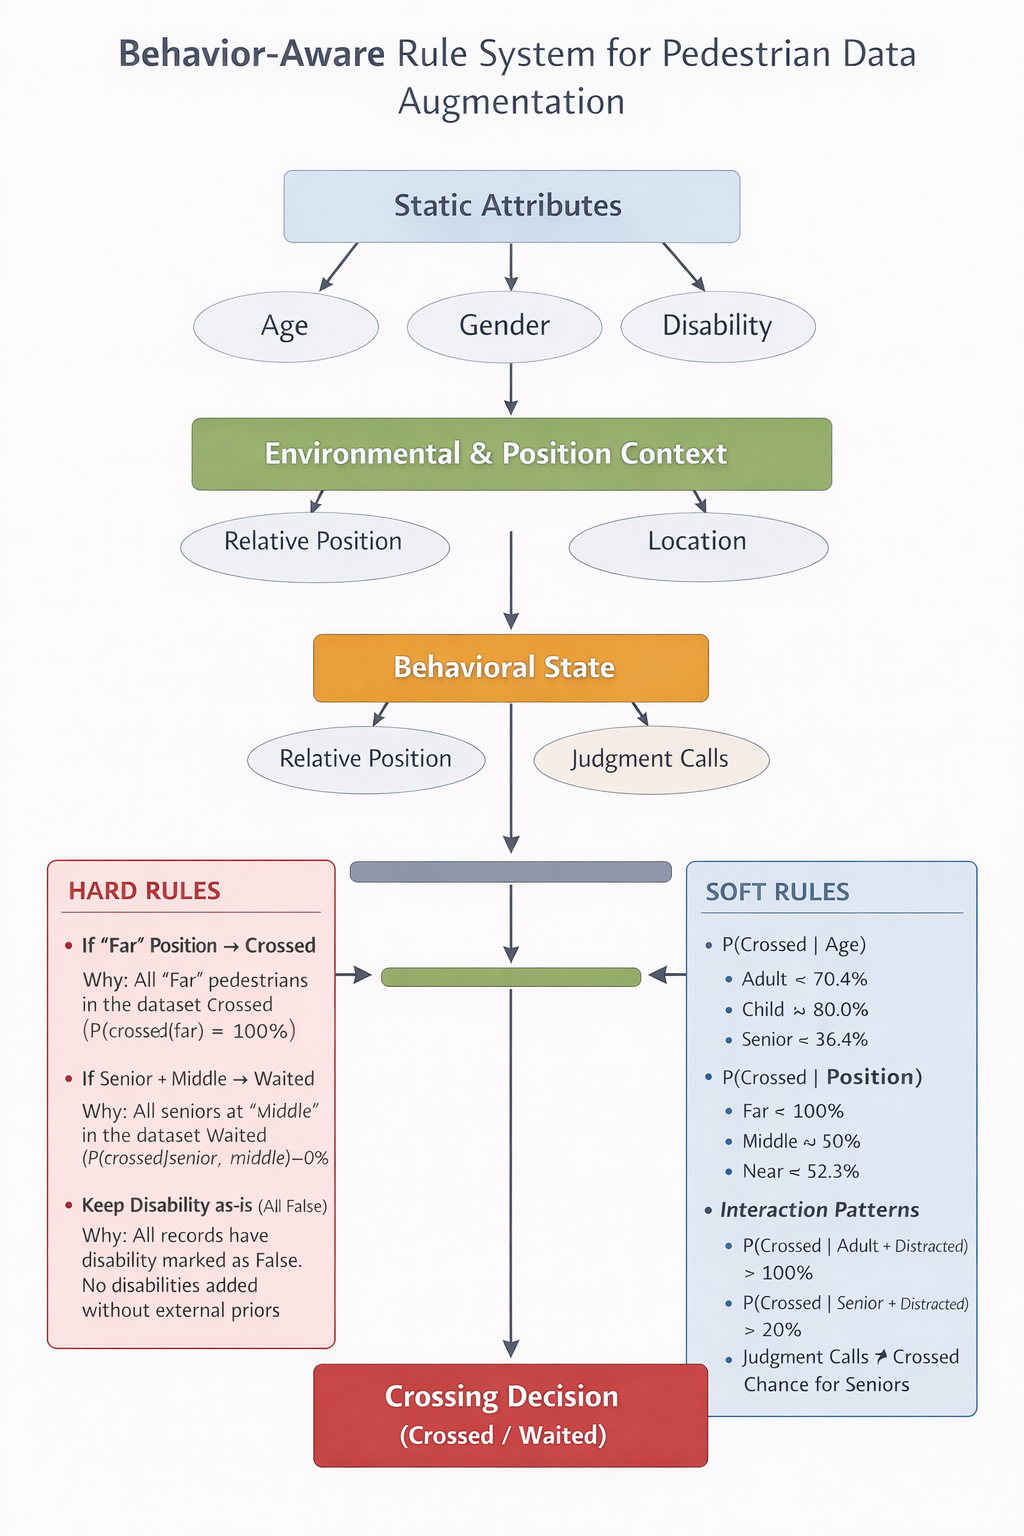

In [ ]:
# --- Behavior-aware augmentation (drop-in) ---
import random
import pandas as pd

def behavior_aware_augment(df, num_aug_per_row=2, random_seed=42):
    """
    df: pandas.DataFrame with columns:
      track_id,age,gender,dresscodestyle,weight,fashionpersonality,
      disability,location,judgmentcalls,distracted,relativeposition,crossed
    Returns augmented DataFrame (original rows + generated rows).
    """
    random.seed(random_seed)

    # Ensure strings are normalized
    df = df.copy().reset_index(drop=True)
    df = df.fillna("unknown").astype(str)

    # Build conditional probability tables from the provided data
    # P(crossed | age, relativeposition, distracted)
    try:
        ctp = pd.crosstab([df['age'], df['relativeposition'], df['distracted']],
                          df['crossed'], normalize='index')
    except Exception:
        ctp = pd.DataFrame()

    # Fallback tables
    ctp_age_rel = pd.crosstab([df['age'], df['relativeposition']], df['crossed'], normalize='index')
    ctp_age = pd.crosstab(df['age'], df['crossed'], normalize='index')

    # Auxiliary conditional tables for sampling behavior features
    p_distracted_by_age = pd.crosstab(df['age'], df['distracted'], normalize='index')
    p_judg_by_age = pd.crosstab(df['age'], df['judgmentcalls'], normalize='index')
    p_rel_by_age = pd.crosstab(df['age'], df['relativeposition'], normalize='index')

    def sample_crossed(age, relpos, distracted):
        # attempt most specific table, then fallback
        key = (age, relpos, distracted)
        if not ctp.empty and key in ctp.index:
            probs = ctp.loc[key]
        elif (age, relpos) in ctp_age_rel.index:
            probs = ctp_age_rel.loc[(age, relpos)]
        elif age in ctp_age.index:
            probs = ctp_age.loc[age]
        else:
            # fallback uninformative
            probs = pd.Series({'crossed': 0.6, 'waited': 0.4})
        p_crossed = float(probs.get('crossed', 0.5))
        return 'crossed' if random.random() < p_crossed else 'waited'

    # Hard validity rules (derived from data)
    def is_valid_profile(row):
        # 1) far => must be crossed
        if row['relativeposition'] == 'far' and row['crossed'] != 'crossed':
            return False
        # 2) senior & middle => should be waited
        if row['age'] == 'senior' and row['relativeposition'] == 'middle' and row['crossed'] == 'crossed':
            return False
        # (You can add more domain-specific rejects here)
        return True

    augmented_rows = []
    for _, base in df.iterrows():
        # keep static traits
        base_static = {
            'age': base['age'],
            'gender': base['gender'],
            'disability': base['disability'],
            'weight': base['weight'],
            'fashionpersonality': base['fashionpersonality'],
            'dresscodestyle': base['dresscodestyle'],
        }
        for i in range(num_aug_per_row):
            new = base.copy()  # start from original row
            # 1) sample 'distracted' conditioned on age (if available)
            if base_static['age'] in p_distracted_by_age.index:
                probs = p_distracted_by_age.loc[base_static['age']].to_dict()
                new['distracted'] = random.choices(list(probs.keys()), weights=list(probs.values()))[0]
            else:
                new['distracted'] = random.choices(['no','yes'], weights=[0.9,0.1])[0]

            # 2) sample 'judgmentcalls' conditioned on age
            if base_static['age'] in p_judg_by_age.index:
                probs = p_judg_by_age.loc[base_static['age']].to_dict()
                new['judgmentcalls'] = random.choices(list(probs.keys()), weights=list(probs.values()))[0]
            else:
                new['judgmentcalls'] = random.choice(['nohandsignal','handsignal'])

            # 3) sample 'relativeposition' conditioned on age (allow plausible movement)
            if base_static['age'] in p_rel_by_age.index:
                probs = p_rel_by_age.loc[base_static['age']].to_dict()
                new['relativeposition'] = random.choices(list(probs.keys()), weights=list(probs.values()))[0]
            else:
                new['relativeposition'] = random.choice(['near','middle','far'])

            # 4) determine 'crossed' using the best-available conditional table
            new['crossed'] = sample_crossed(new['age'], new['relativeposition'], new['distracted'])

            # 5) assign new track id
            new['track_id'] = f"{base['track_id']}_aug{i+1}"

            # 6) validate & keep if OK (reject otherwise)
            if is_valid_profile(new):
                augmented_rows.append(new)

    df_aug = pd.DataFrame(augmented_rows)
    df_out = pd.concat([df, df_aug], ignore_index=True)
    # Reset index and return
    return df_out.reset_index(drop=True)

# Example usage:
df = pd.read_csv("/content/crossing_annotations.csv")  # the DataFrame you gave
df_augmented = behavior_aware_augment(df, num_aug_per_row=4)
df_augmented.to_csv("crossing_annotations_behavior_aware_aug.csv", index=False)


In [ ]:
df_augmented.shape

(300, 12)

In [ ]:
df.head()

,track_id,age,gender,dresscodestyle,weight,fashionpersonality,disability,location,judgmentcalls,distracted,relativeposition,crossed
0,V1_14,senior,male,formal,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,near,waited
1,V1_25,senior,male,formal,normalweight,minimalist,False,onsidewalk,nohandsignal,yes,middle,waited
2,V1_27,senior,male,formal,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,far,crossed
3,V1_32,child,male,casual,normalweight,minimalist,False,notonsidewalk,nohandsignal,no,far,crossed
4,V1_34,senior,female,formal,normalweight,minimalist,False,notonsidewalk,handsignal,no,near,waited


# behavior-aware augmentation



> *We implemented a behavior-aware augmentation pipeline. Rather than randomly flipping fields, we derived semantic constraints and conditional probabilities from the labeled dataset and used them to generate new, plausible pedestrian profiles. Hard constraints (e.g., pedestrians observed at `far` always crossed) were enforced; behavioral variables (`distracted`, `judgmentcalls`, `crossed`) were sampled from conditional distributions (e.g., P(crossed | age, relativeposition, distracted)). Any generated profile violating hard plausibility rules was rejected. This approach increases sample size while preserving human realism and reduces the risk of implausible examples (e.g., “senior with crutches sprinting across road”).*

---

# Limitations & next steps (be explicit in thesis)

* **Augmentation ≠ new independent observations.** It helps regularize models but does not replace collecting more real pedestrians.
* **Small-original-sample risk.** Some conditional probabilities are estimated from few examples (e.g., child groups). Mark those estimates as low-confidence.
* **Suggestion:** If you can, combine this with *external priors* (traffic behavior studies) or carefully annotated additional examples to improve the conditional probability estimates.

---



In [ ]:
df=df_augmented

## 2. Target Variable Exploration (Crossed)

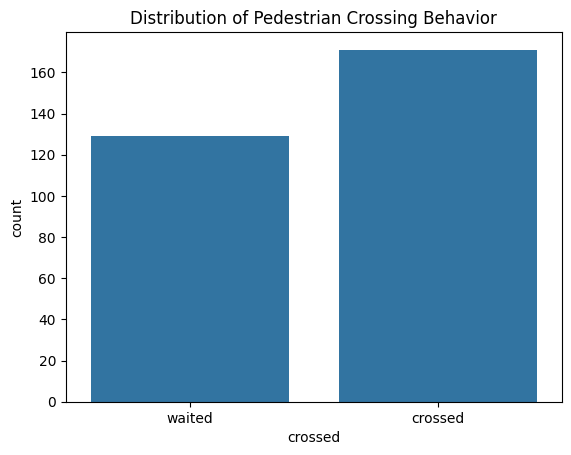

crossed
crossed    0.57
waited     0.43
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of target variable
sns.countplot(data=df, x="crossed")
plt.title("Distribution of Pedestrian Crossing Behavior")
plt.show()

print(df["crossed"].value_counts(normalize=True))


## 3. Univariate Analysis

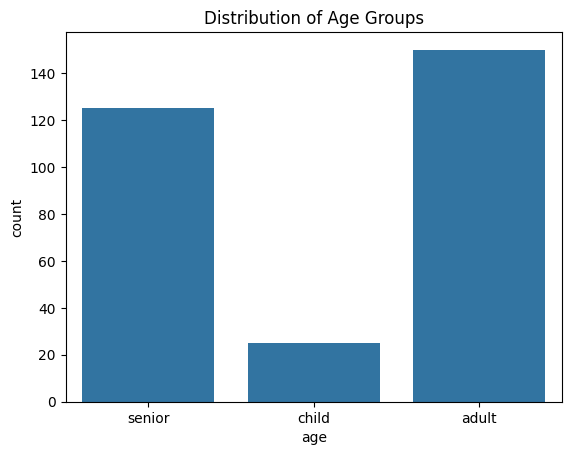

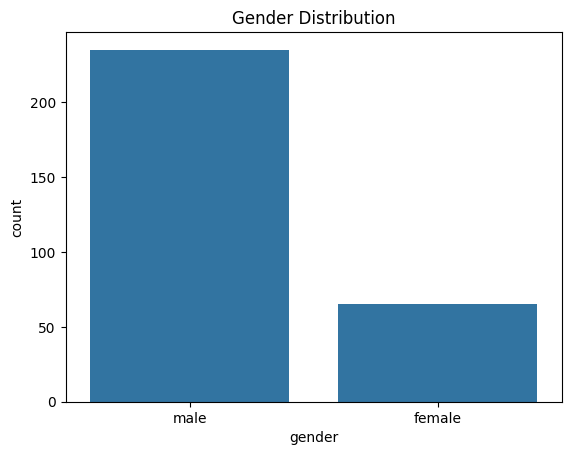

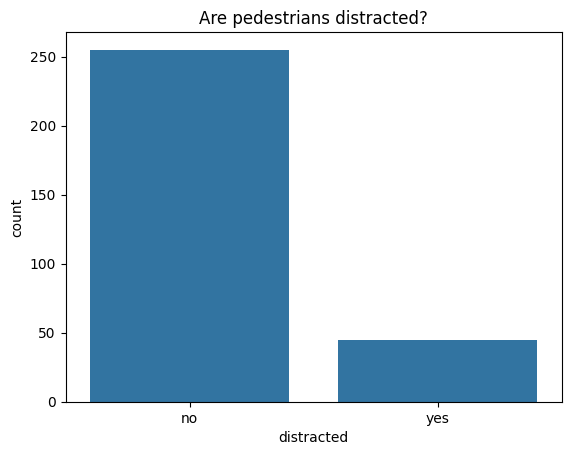

In [ ]:
# Age groups distribution
sns.countplot(data=df, x="age")
plt.title("Distribution of Age Groups")
plt.show()

# Gender distribution
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

# Distraction levels
sns.countplot(data=df, x="distracted")
plt.title("Are pedestrians distracted?")
plt.show()


## 4. Bivariate Analysis (Feature vs Crossing)

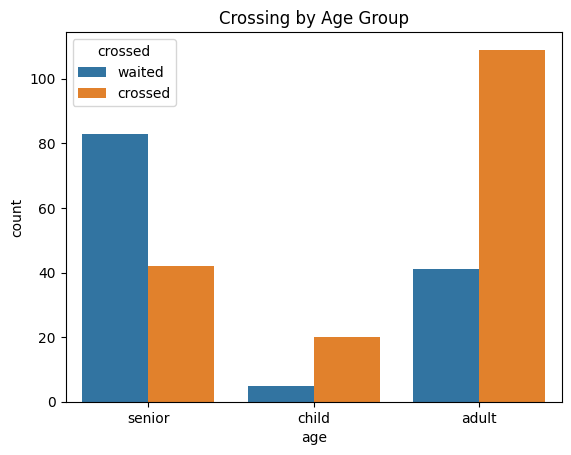

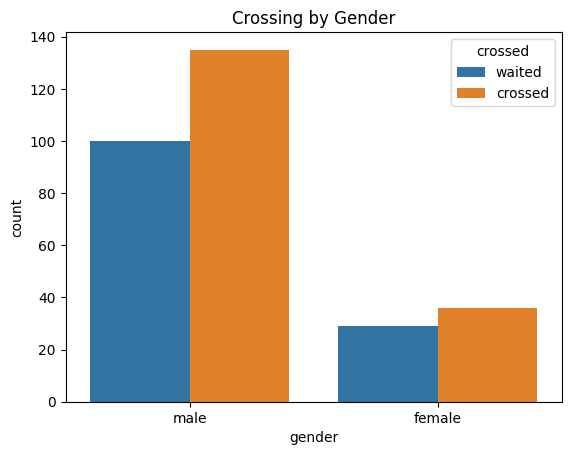

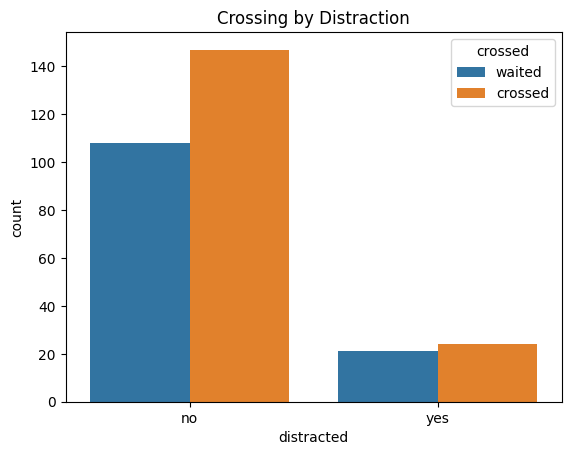

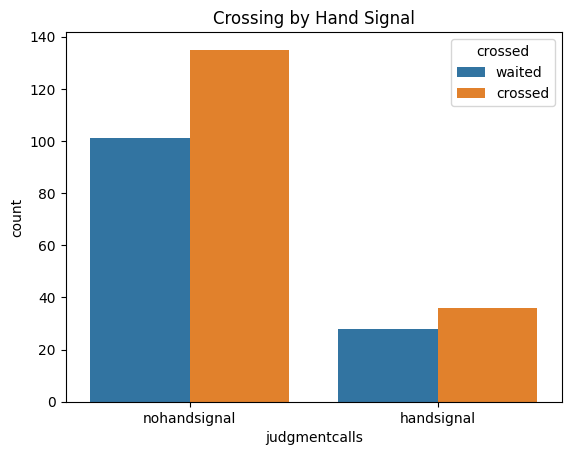

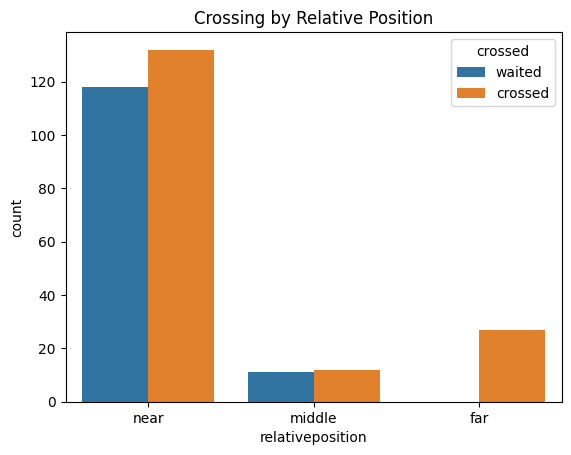

In [ ]:
# Age vs Crossing
sns.countplot(data=df, x="age", hue="crossed")
plt.title("Crossing by Age Group")
plt.show()

# Gender vs Crossing
sns.countplot(data=df, x="gender", hue="crossed")
plt.title("Crossing by Gender")
plt.show()

# Distracted vs Crossing
sns.countplot(data=df, x="distracted", hue="crossed")
plt.title("Crossing by Distraction")
plt.show()

# Hand signals vs Crossing
sns.countplot(data=df, x="judgmentcalls", hue="crossed")
plt.title("Crossing by Hand Signal")
plt.show()

# Relative position vs Crossing
sns.countplot(data=df, x="relativeposition", hue="crossed")
plt.title("Crossing by Relative Position")
plt.show()


## 2 Class Balance Check

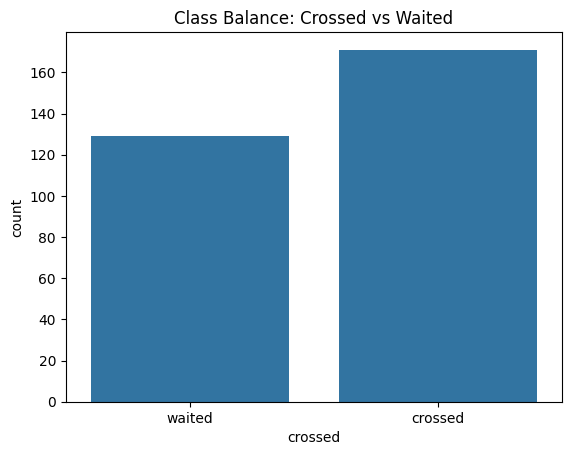

Class Distribution:
crossed
crossed    0.57
waited     0.43
Name: proportion, dtype: float64


In [ ]:
sns.countplot(data=df, x="crossed")
plt.title("Class Balance: Crossed vs Waited")
plt.show()

class_balance = df["crossed"].value_counts(normalize=True)
print("Class Distribution:")
print(class_balance)

## 3.1 Distribution of crossing behavior

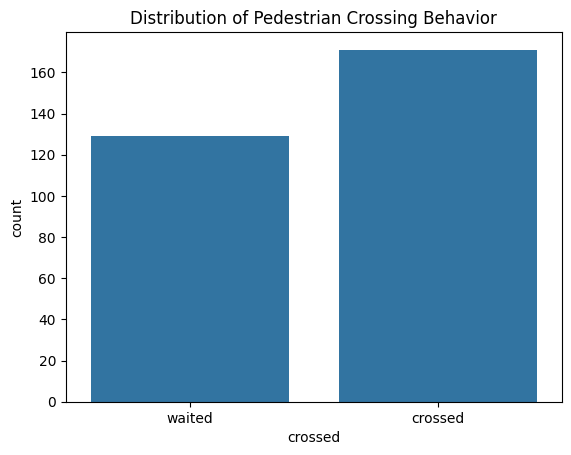

In [ ]:
sns.countplot(data=df, x="crossed")
plt.title("Distribution of Pedestrian Crossing Behavior")
plt.show()

# 3.2 Age vs Crossing

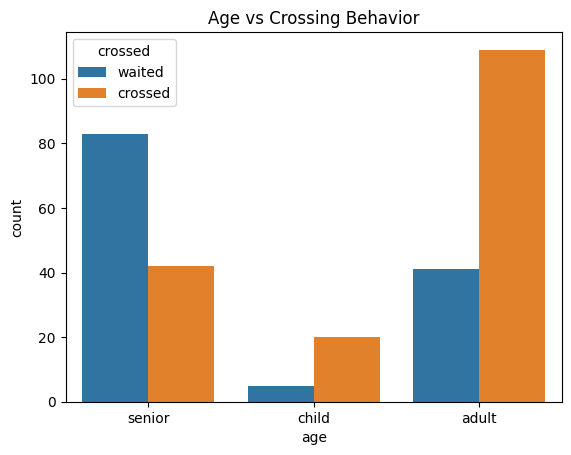

In [ ]:
sns.countplot(data=df, x="age", hue="crossed")
plt.title("Age vs Crossing Behavior")
plt.show()

## 3.3 Gender vs Crossing

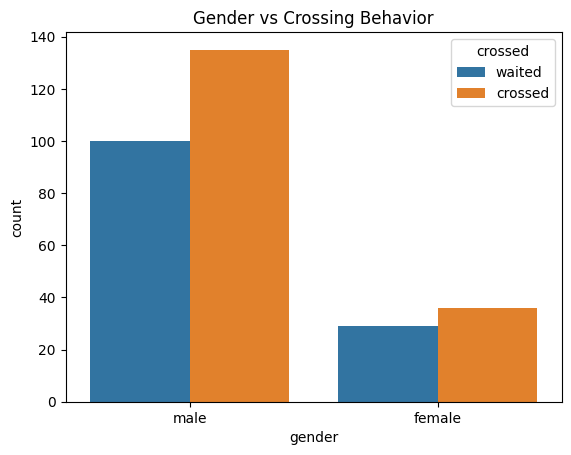

In [ ]:
sns.countplot(data=df, x="gender", hue="crossed")
plt.title("Gender vs Crossing Behavior")
plt.show()

## 3.4 Distraction vs Crossing

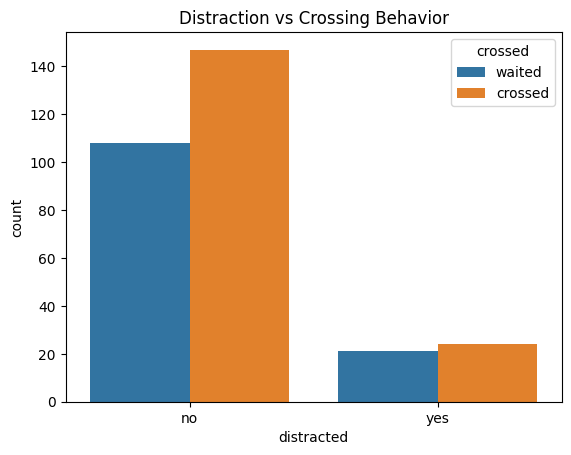

In [ ]:
sns.countplot(data=df, x="distracted", hue="crossed")
plt.title("Distraction vs Crossing Behavior")
plt.show()

## 3.5 Hand Signal vs Crossing


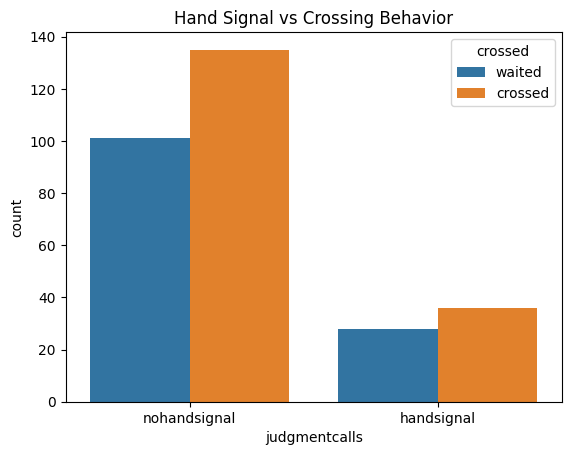

In [ ]:
sns.countplot(data=df, x="judgmentcalls", hue="crossed")
plt.title("Hand Signal vs Crossing Behavior")
plt.show()

# 3.6 Relative Position vs Crossing

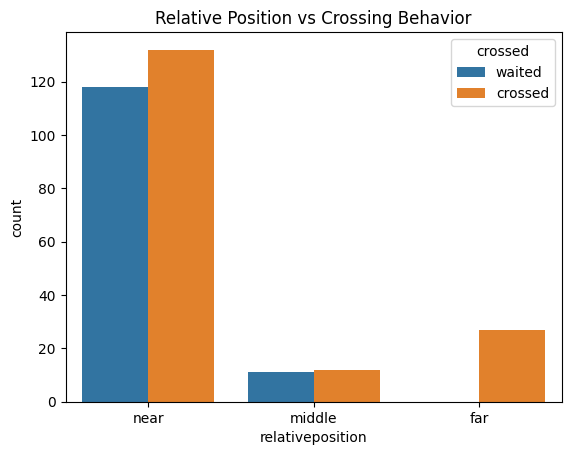

In [ ]:
sns.countplot(data=df, x="relativeposition", hue="crossed")
plt.title("Relative Position vs Crossing Behavior")
plt.show()

## 3.7 Dress Code vs Crossing

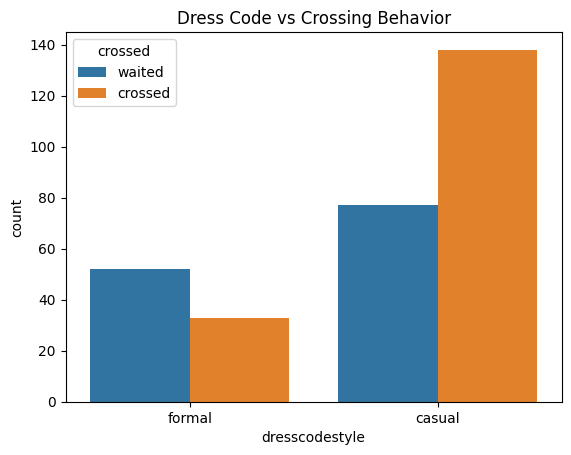

In [ ]:
sns.countplot(data=df, x="dresscodestyle", hue="crossed")
plt.title("Dress Code vs Crossing Behavior")
plt.show()

## 3.8 Location vs Crossing


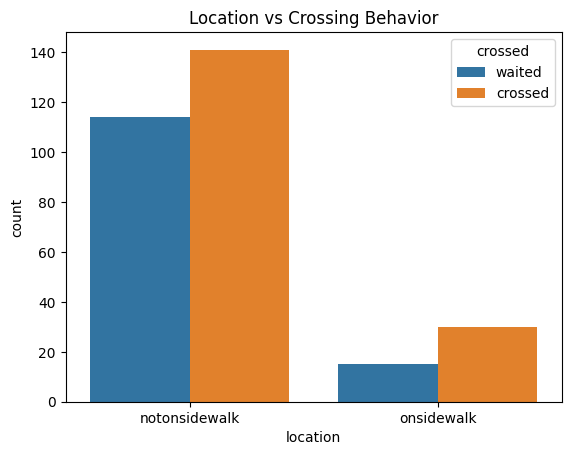

In [ ]:
sns.countplot(data=df, x="location", hue="crossed")
plt.title("Location vs Crossing Behavior")
plt.show()

## 3.9 Age vs Distraction Interaction

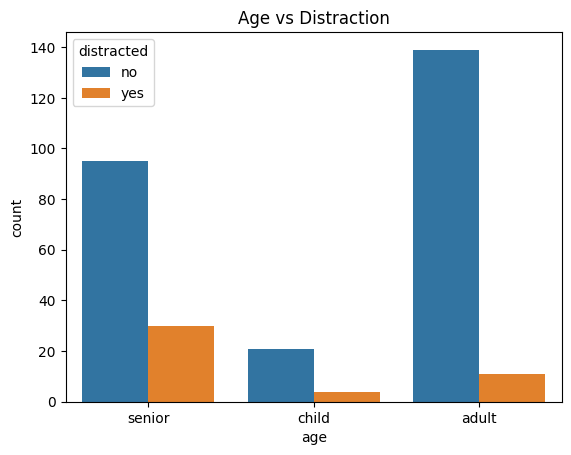

In [ ]:
sns.countplot(data=df, x="age", hue="distracted")
plt.title("Age vs Distraction")
plt.show()

## 3.10 Gender & Hand Signal Interaction

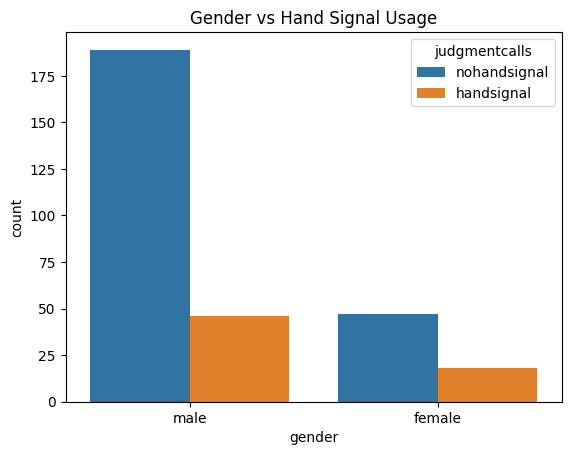

In [ ]:
sns.countplot(data=df, x="gender", hue="judgmentcalls")
plt.title("Gender vs Hand Signal Usage")
plt.show()

## 3.11 Age vs Relative Position

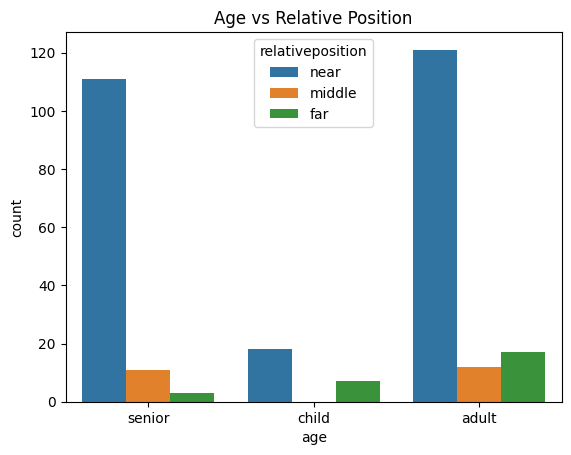

In [ ]:
sns.countplot(data=df, x="age", hue="relativeposition")
plt.title("Age vs Relative Position")
plt.show()

## 3.12 Distraction vs Hand Signal

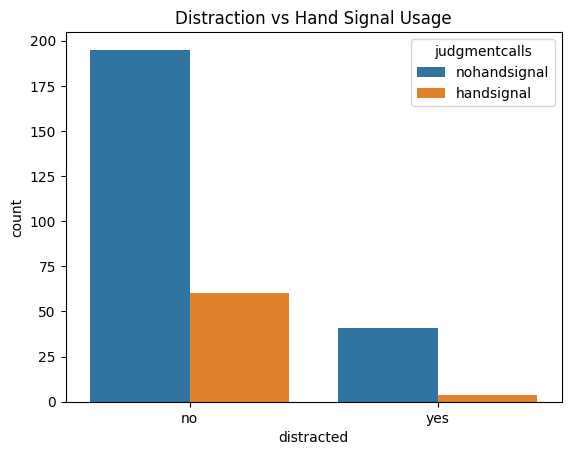

In [ ]:
sns.countplot(data=df, x="distracted", hue="judgmentcalls")
plt.title("Distraction vs Hand Signal Usage")
plt.show()


## 3.13 Combined Risk Profiles (Cross-tab)

In [ ]:
risk_table = pd.crosstab(
    [df["age"], df["distracted"], df["location"]],
    df["crossed"],
    normalize="index"
)
print("Crossing Probabilities by Age + Distraction + Location:")
print(risk_table)

Crossing Probabilities by Age + Distraction + Location:
crossed                           crossed    waited
age    distracted location                         
adult  no         notonsidewalk  0.688525  0.311475
                  onsidewalk     0.823529  0.176471
       yes        notonsidewalk  1.000000  0.000000
                  onsidewalk     1.000000  0.000000
child  no         notonsidewalk  0.812500  0.187500
                  onsidewalk     0.600000  0.400000
       yes        notonsidewalk  1.000000  0.000000
senior no         notonsidewalk  0.304878  0.695122
                  onsidewalk     0.615385  0.384615
       yes        notonsidewalk  0.304348  0.695652
                  onsidewalk     0.285714  0.714286


## 3.14 Chi-Square Tests

In [ ]:
from scipy.stats import chi2_contingency

categorical_vars = ["age", "gender", "distracted", "judgmentcalls", "location", "relativeposition"]
for col in categorical_vars:
    contingency = pd.crosstab(df[col], df["crossed"])
    chi2, p, dof, ex = chi2_contingency(contingency)
    print(f"Chi-square Test for {col} vs Crossed: p-value = {p:.4f}")


Chi-square Test for age vs Crossed: p-value = 0.0000
Chi-square Test for gender vs Crossed: p-value = 0.8763
Chi-square Test for distracted vs Crossed: p-value = 0.7072
Chi-square Test for judgmentcalls vs Crossed: p-value = 1.0000
Chi-square Test for location vs Crossed: p-value = 0.2086
Chi-square Test for relativeposition vs Crossed: p-value = 0.0000


## 3.15 Correlation Between Encoded Features

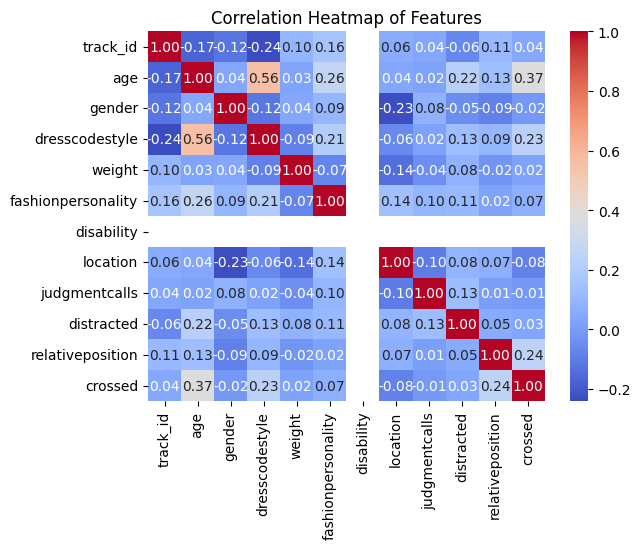

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == "object" or df_encoded[col].dtype == "bool":
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()


## 3.16 Conditional Probability (P(Crossed | Distracted, Hand Signal))

In [ ]:
cond_prob = pd.crosstab([df["distracted"], df["judgmentcalls"]], df["crossed"], normalize="index")
print("Conditional Probability of Crossing given Distracted & Hand Signal:")
print(cond_prob)

Conditional Probability of Crossing given Distracted & Hand Signal:
crossed                    crossed    waited
distracted judgmentcalls                    
no         handsignal     0.566667  0.433333
           nohandsignal   0.579487  0.420513
yes        handsignal     0.500000  0.500000
           nohandsignal   0.536585  0.463415


## 3.17 Bayesian Analysis Example

In [ ]:
p_crossed = (df["crossed"] == "crossed").mean()
p_distracted = (df["distracted"] == "yes").mean()
p_crossed_and_distracted = ((df["crossed"] == "crossed") & (df["distracted"] == "yes")).mean()

bayes_prob = p_crossed_and_distracted / p_distracted
print(f"P(Crossed | Distracted=yes) using Bayes = {bayes_prob:.3f}")

P(Crossed | Distracted=yes) using Bayes = 0.533


#4. Data Preprocessing for ML


## Encode categorical variables

In [ ]:
le = LabelEncoder()
df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == "object" or df_encoded[col].dtype == "bool":
        df_encoded[col] = le.fit_transform(df_encoded[col])


In [ ]:
df_encoded.head()

,track_id,age,gender,dresscodestyle,weight,fashionpersonality,disability,location,judgmentcalls,distracted,relativeposition,crossed
0,0,2,1,1,0,1,0,0,1,0,2,1
1,5,2,1,1,0,1,0,1,1,1,1,1
2,10,2,1,1,0,1,0,0,1,0,0,0
3,15,1,1,0,0,1,0,0,1,0,0,0
4,20,2,0,1,0,1,0,0,0,0,2,1


In [ ]:

# Features and target
X = df_encoded.drop(["track_id", "crossed","disability"], axis=1)  # drop both columns
y = df_encoded["crossed"]

## Split data


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Modeling

## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# Predictions


In [ ]:
y_pred = model.predict(X_test)

# Evaluation

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78        34
           1       0.72      0.69      0.71        26

    accuracy                           0.75        60
   macro avg       0.75      0.74      0.74        60
weighted avg       0.75      0.75      0.75        60

Confusion Matrix:
[[27  7]
 [ 8 18]]


# 6. Feature Importance

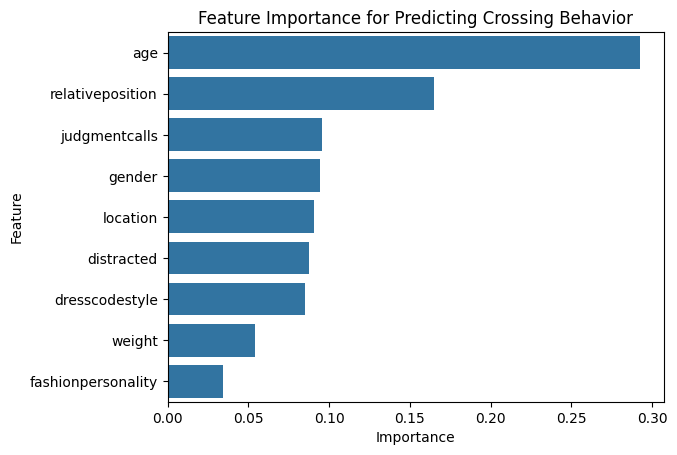

In [ ]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance for Predicting Crossing Behavior")
plt.show()